In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Setup and Load Data

plt.style.use("fivethirtyeight")
plt.rcParams["figure.figsize"] = (20, 5)
plt.rcParams["figure.dpi"] = 100

df = pd.read_pickle("../../data/processed/data_processed.pkl")

os.makedirs("../../reports/figures/", exist_ok=True)


Mục đích: Kiểm tra sự phân bố số lượng mẫu giữa các lớp hoạt động để phát hiện class imbalance.
Nếu một lớp có quá nhiều mẫu (over-represented) trong khi lớp khác quá ít, mô hình sẽ bias về lớp đa số, dẫn đến accuracy cao nhưng recall/precision thấp trên lớp thiểu số.
Các hoạt động sit, std, wlk có khoảng 30.000–35.000 mẫu (rất cân bằng), trong khi dws, jog, ups chỉ khoảng 12.000–15.000 mẫu → tồn tại imbalance nhẹ (tỷ lệ khoảng 2:1) =>  cân nhắc sử dụng class weights, oversampling (SMOTE) cho các lớp thiểu số hoặc đánh giá mô hình bằng metric như macro-F1 thay vì accuracy.

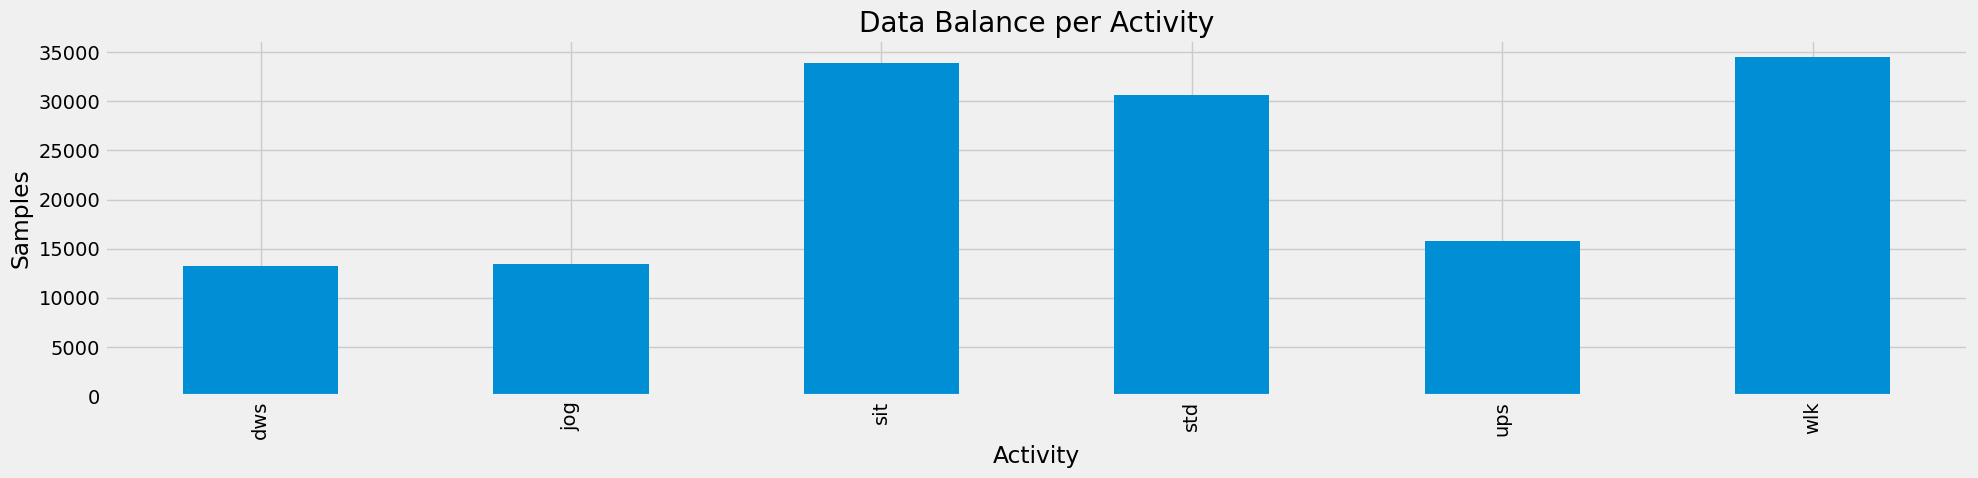

In [3]:
# 2. Data Balance

balance = df["category"].value_counts().sort_index()

plt.figure()
balance.plot(kind="bar")
plt.title("Data Balance per Activity")
plt.xlabel("Activity")
plt.ylabel("Samples")
plt.tight_layout()
plt.savefig("../../reports/figures/data_balance.png", dpi=150)
plt.show()


Mục đích 
Hiển thị tín hiệu thô của trục acceleration Y trong một set dữ liệu liên tục để kiểm tra chất lượng và hình dạng tín hiệu gốc.
=> Giúp phát hiện noise/outlier/drift sớm, hiểu pattern chu kỳ, đánh giá cần tiền xử lý gì (filter, normalize, tách gravity), và đoán sơ bộ loại hoạt động.

Pattern chu kỳ rõ rệt: Đỉnh và đáy lặp lại đều đặn (chu kỳ ≈12–15 samples), đặc trưng điển hình của hoạt động walking (mỗi bước chân tạo lực tác động lên trục Y).
Biên độ ổn định: Dao động từ ≈0.6 đến ≈1.3, biên độ mỗi chu kỳ ≈0.6–0.7, không thay đổi đột ngột → người thực hiện hoạt động đều tốc độ.
Offset dương mạnh: Giá trị trung bình ≈1.0 (gần +1g) → thành phần gravity vẫn còn, trục Y hướng gần thẳng đứng (thiết bị đeo ở hông/thắt lưng).
Tín hiệu sạch: Ít nhiễu cao tần, không có spike bất thường.

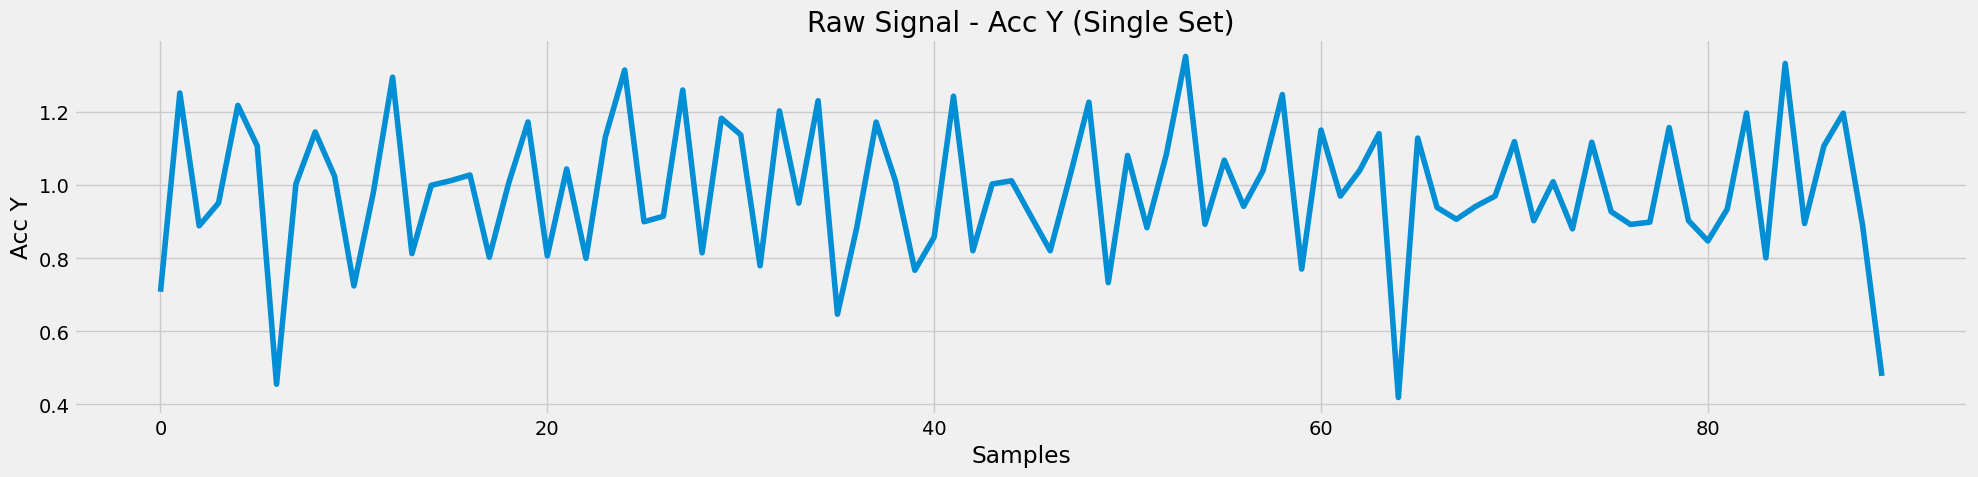

In [ ]:

# 3. Explore Single Columns

set_id = df["set"].iloc[0]
set_df = df[df["set"] == set_id]

plt.figure()
plt.plot(set_df["acc_y"].reset_index(drop=True))
plt.title("Raw Signal - Acc Y (Single Set)")
plt.xlabel("Samples")
plt.ylabel("Acc Y")
plt.tight_layout()
plt.savefig("../../reports/figures/raw_signal_acc_y.png", dpi=150)
plt.show()


Code này dùng để visualize tín hiệu gia tốc (accelerometer signals) từ dữ liệu cảm biến cho từng loại hoạt động con người riêng biệt
=> Thể hiện đặc trưng của hoạt động tĩnh, giúp dễ dàng phân biệt với các hoạt động động trong HAR.


DWS (Downstairs) và UPS (Upstairs):
Biến động mạnh ở một số trục (đặc biệt y và z), có các "burst" (đỉnh cao đột ngột) ở đầu và cuối segment.
Có xu hướng drift (dịch chuyển dần) ở một số trục do ảnh hưởng trọng lực khi thay đổi độ cao.
Đặc trưng: Tín hiệu không đều, có pha chuyển tiếp mạnh → phản ánh bước chân lên/xuống cầu thang.

JOG (Jogging):
Biến động rất mạnh và lặp lại (periodic) ở hầu hết các trục, đặc biệt y (red) dao động lớn quanh 1.0–2.0.
Tần số cao, amplitude lớn → phản ánh nhịp chạy bộ nhanh, lực tác động mạnh liên tục.

WLK (Walking):
Dao động periodic rõ rệt, đều đặn ở tất cả 3 trục (như sóng sin chồng chéo).
Amplitude trung bình, lặp lại nhịp nhàng → đặc trưng của bước đi bộ bình thường, chu kỳ bước chân rõ ràng.

SIT (Sitting):
Tín hiệu gần như phẳng, biến động rất nhỏ (chỉ nhiễu nhẹ).
Các trục ổn định ở giá trị cố định (ví dụ z ~ -0.9 do trọng lực) → phản ánh trạng thái tĩnh, ít chuyển động.

STD (Standing):
Tương tự SIT nhưng có drift nhẹ ở một số trục (x giảm dần).
Biến động nhỏ hơn hoạt động động, nhưng có thể có nhiễu do tư thế đứng.

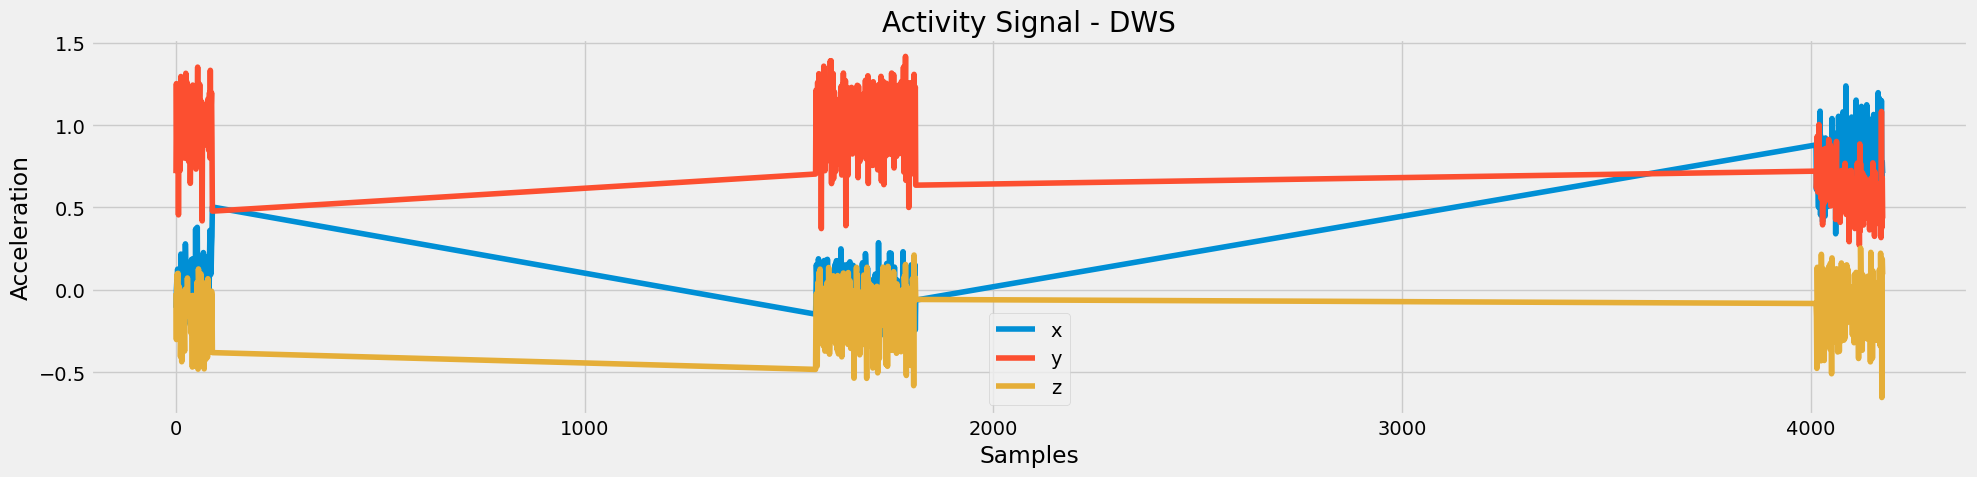

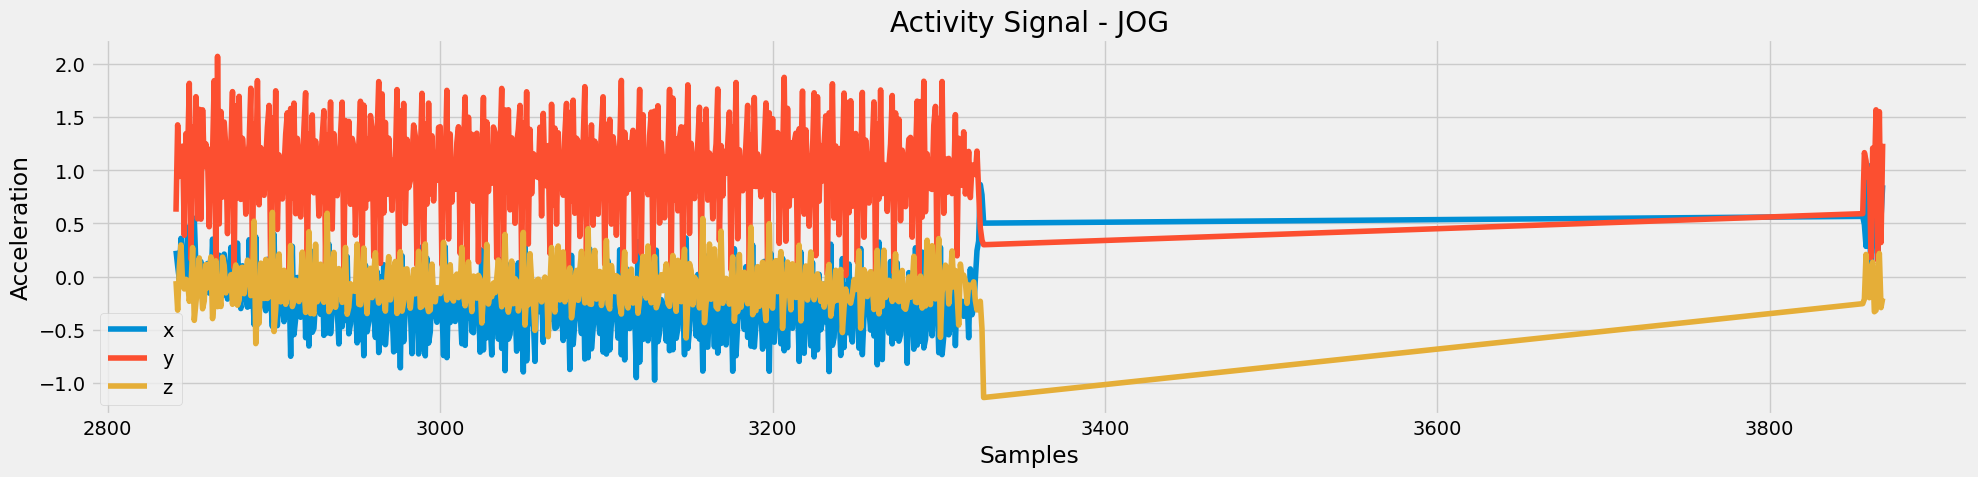

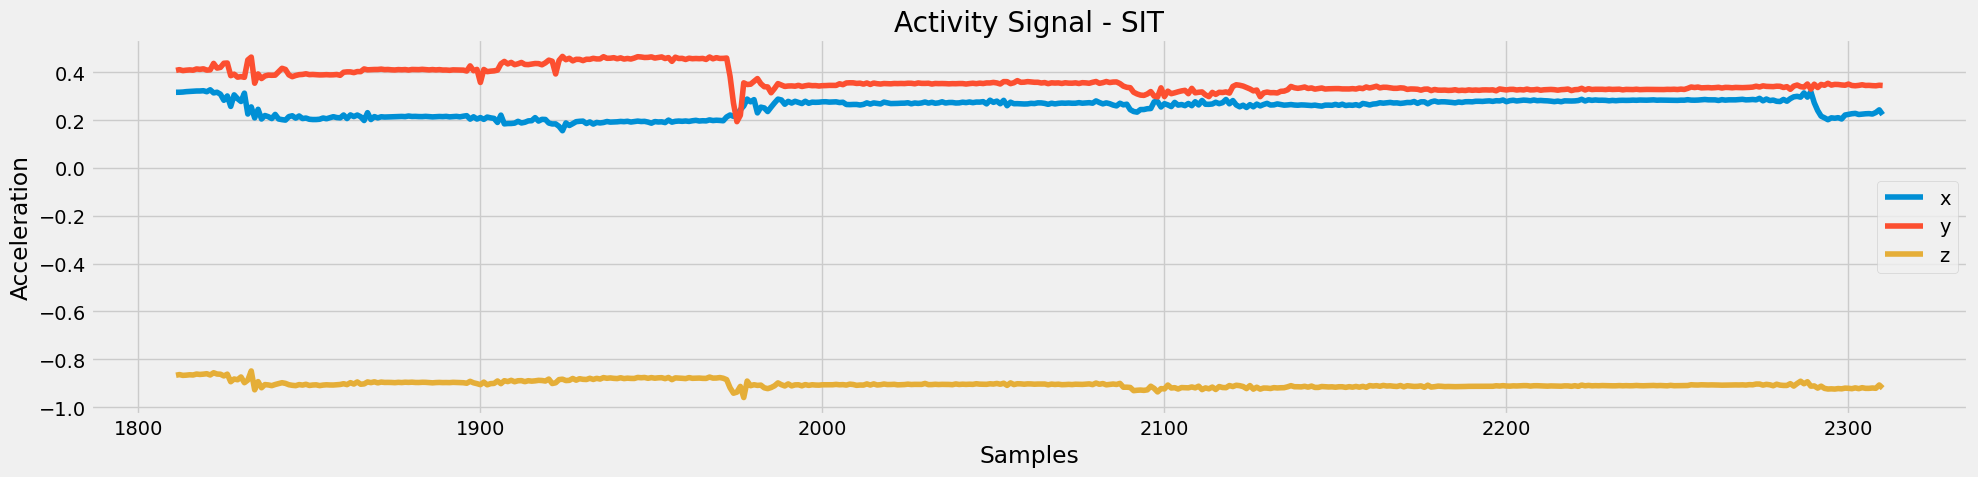

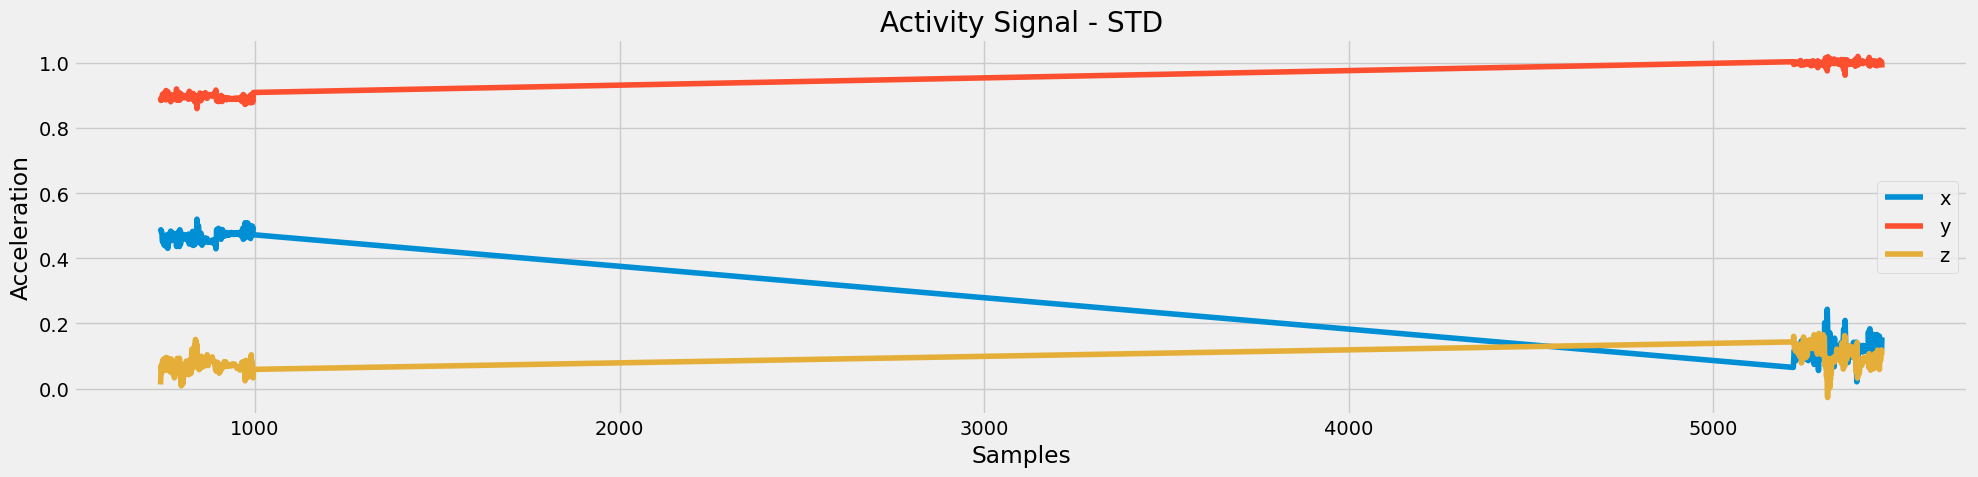

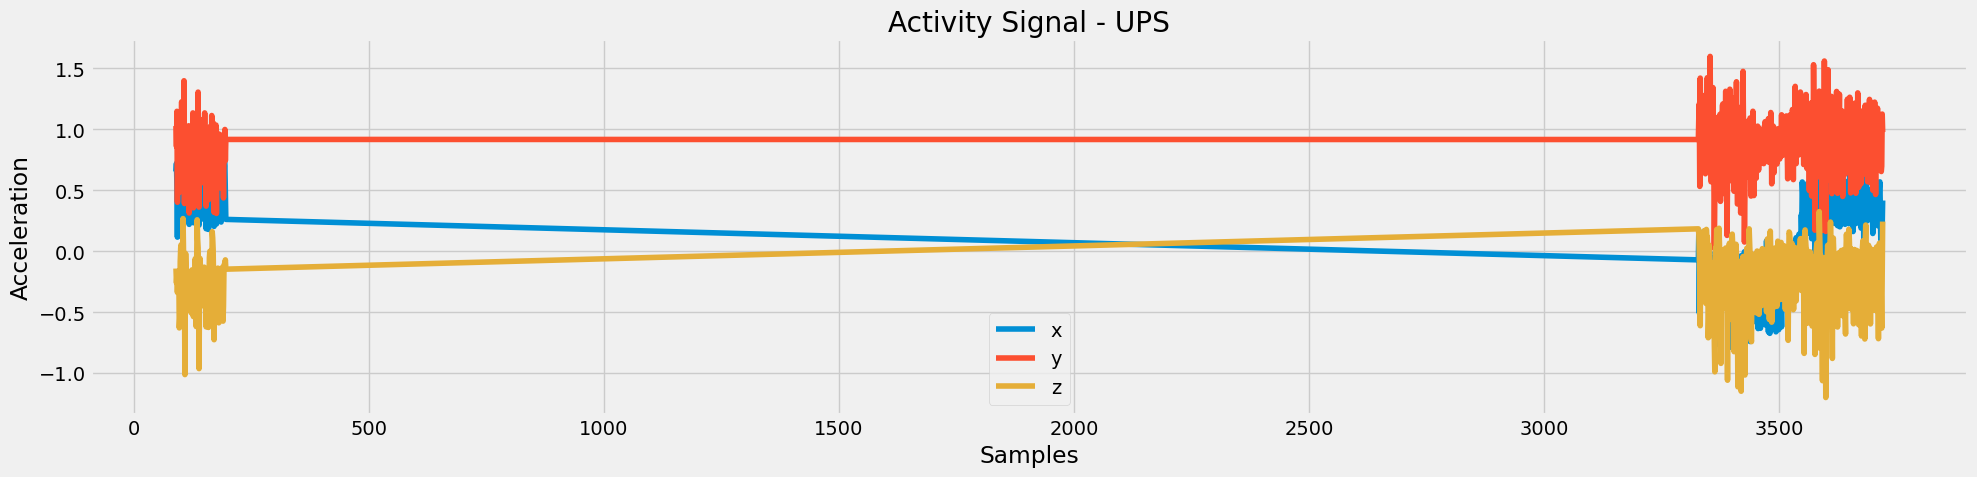

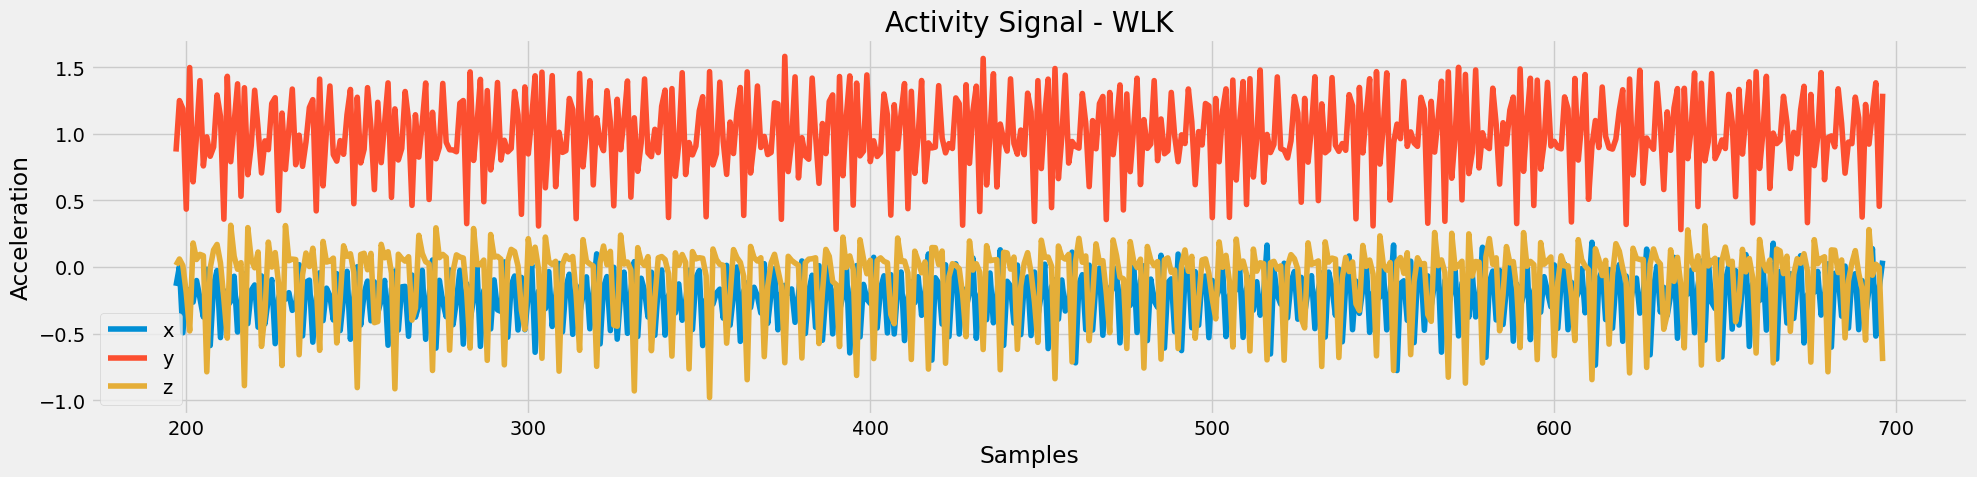

In [ ]:

# 4. Plot All Activities

labels = sorted(df["category"].unique())

for label in labels:
    subset = df[df["category"] == label].head(500)

    plt.figure()
    plt.plot(subset["acc_x"], label="x")
    plt.plot(subset["acc_y"], label="y")
    plt.plot(subset["acc_z"], label="z")
    plt.title(f"Activity Signal - {label.upper()}")
    plt.xlabel("Samples")
    plt.ylabel("Acceleration")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"../../reports/figures/timeseries_{label}.png", dpi=150)
    plt.show()


Biểu đồ này nhằm mục đích so sánh sự khác biệt về đặc tính tín hiệu gia tốc (trục Y) của cùng một hoạt động đi bộ (WLK) giữa hai người dùng khác nhau
=> Kiểm tra xem dữ liệu của cùng một hoạt động có tính nhất quán hay có sự biến thiên lớn giữa các cá nhân, từ đó đánh giá độ khó của bài toán phân loại hoạt động (Activity Recognition).

Tính chu kỳ (Periodicity): Cả hai người dùng đều thể hiện các đỉnh (peaks) và đáy (troughs) lặp đi lặp lại rất rõ rệt. Đây là đặc trưng điển hình của hoạt động đi bộ (mỗi chu kỳ tương ứng với một bước chân).

Biên độ (Amplitude):
    User_1 (xanh): Có biên độ dao động rộng hơn, các đỉnh cao hơn và đáy thấp hơn (dao động từ khoảng 0.4 đến 1.5). Điều này có thể cho thấy người này đi bước mạnh hơn hoặc vị trí đặt thiết bị có độ rung lắc lớn hơn.
    User_2 (cam): Tín hiệu có vẻ "hẹp" hơn một chút, ngoại trừ một điểm bất thường (spike) rất cao vượt mức 1.8 ở khoảng mẫu thứ 310.

Sự khác biệt về tần số: Nếu quan sát kỹ, các đỉnh của User_1 và User_2 không hoàn toàn khớp nhau về mặt thời gian. Điều này chứng tỏ tốc độ bước đi (cadence) của hai người là khác nhau.

Nhiễu và Điểm dị biệt: Cú vọt lên đột ngột của User_2 tại mẫu 310 có thể là một nhiễu kỹ thuật hoặc một hành động bất ngờ (vấp ngã, đổi hướng) không phản ánh đúng nhịp đi bộ thông thường.

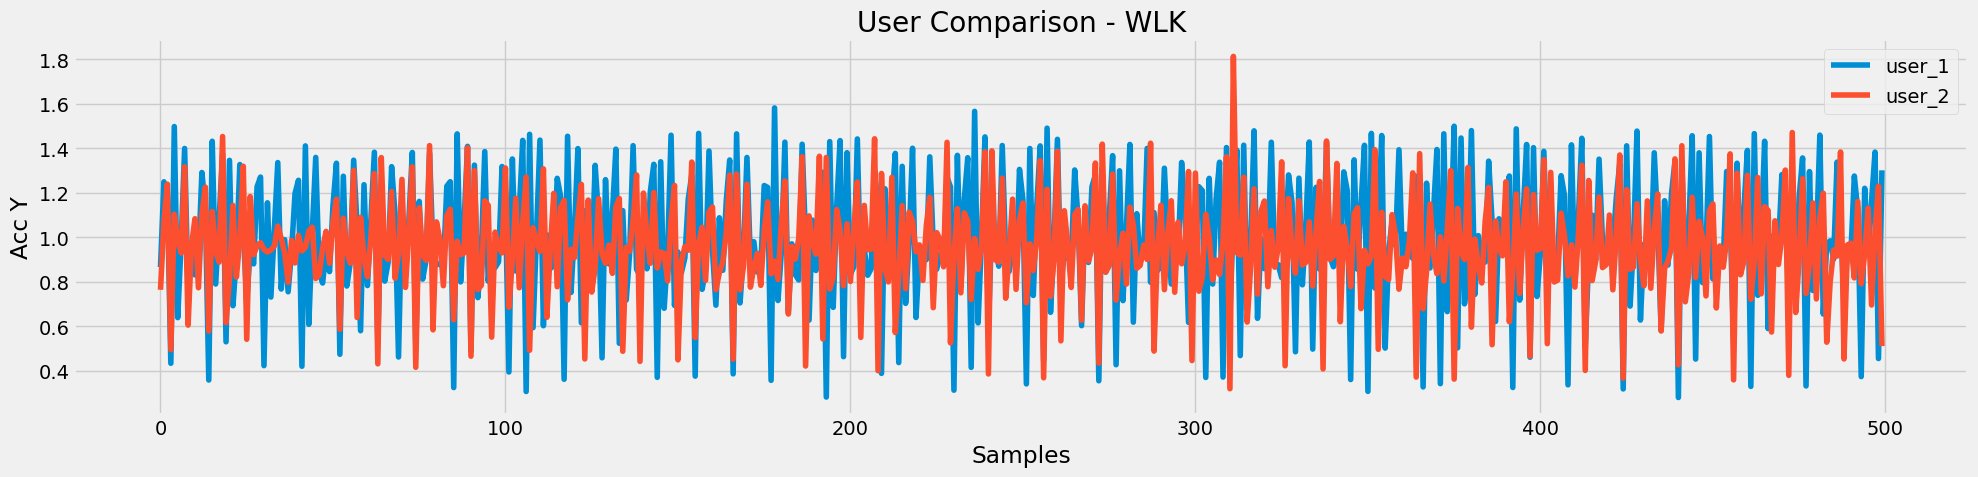

In [7]:

# 5. Compare Participants

activity = "wlk"
users = df[df["category"] == activity]["user_id"].unique()[:2]

plt.figure()
for u in users:
    u_df = df[(df["category"] == activity) & (df["user_id"] == u)].head(500)
    plt.plot(u_df["acc_y"].reset_index(drop=True), label=f"user_{u}")
plt.title(f"User Comparison - {activity.upper()}")
plt.xlabel("Samples")
plt.ylabel("Acc Y")
plt.legend()
plt.tight_layout()
plt.savefig(f"../../reports/figures/user_comparison_{activity}.png", dpi=150)
plt.show()


Biểu đồ này biểu diễn sự biến thiên của gia tốc trên cả 3 trục (x, y, z) cho hoạt động chạy bộ (JOG) của một người dùng duy nhất
=> quan sát sự phối hợp giữa các phương hướng chuyển động, giúp xác định trục nào chứa nhiều thông tin đặc trưng nhất cho hoạt động này.

Trục Y có biên độ dao động lớn nhất và nằm ở mức giá trị cao nhất (trung bình quanh mức 1.0). Điều này cực kỳ hợp lý vì trong hoạt động chạy/đi bộ, lực tác động lớn nhất thường nằm ở trục dọc (Vertical), tương ứng với phản lực từ mặt đất mỗi khi chân chạm đất.

Đặc điểm của trục X (xanh dương) và Z (vàng):
    Hai trục này dao động quanh mức 0, cho thấy thiết bị đo được gia tốc trung bình bằng 0 trên các phương ngang/hông.
    Tuy nhiên, trục X và Z vẫn có tính chu kỳ rất rõ nét, tương ứng với sự rung lắc sang hai bên hoặc chuyển động tiến về phía trước của cơ thể.

Mật độ dao động: So với biểu đồ đi bộ (WLK) trước đó, biểu đồ JOG này có mật độ các đỉnh dày đặc hơn và biên độ cao hơn (trục Y chạm mức 2.0). Điều này phản ánh đúng thực tế là chạy bộ có tần số bước (cadence) cao hơn và lực tác động mạnh hơn đi bộ.

Sự bất thường ở cuối tín hiệu: Khoảng sau mẫu thứ 480, có một sự xáo trộn mạnh ở cả 3 trục (trục Z giảm sâu, trục X vọt lên). Đây có thể là khoảnh khắc người dùng dừng lại, thay đổi tư thế hoặc tắt thiết bị ghi âm.

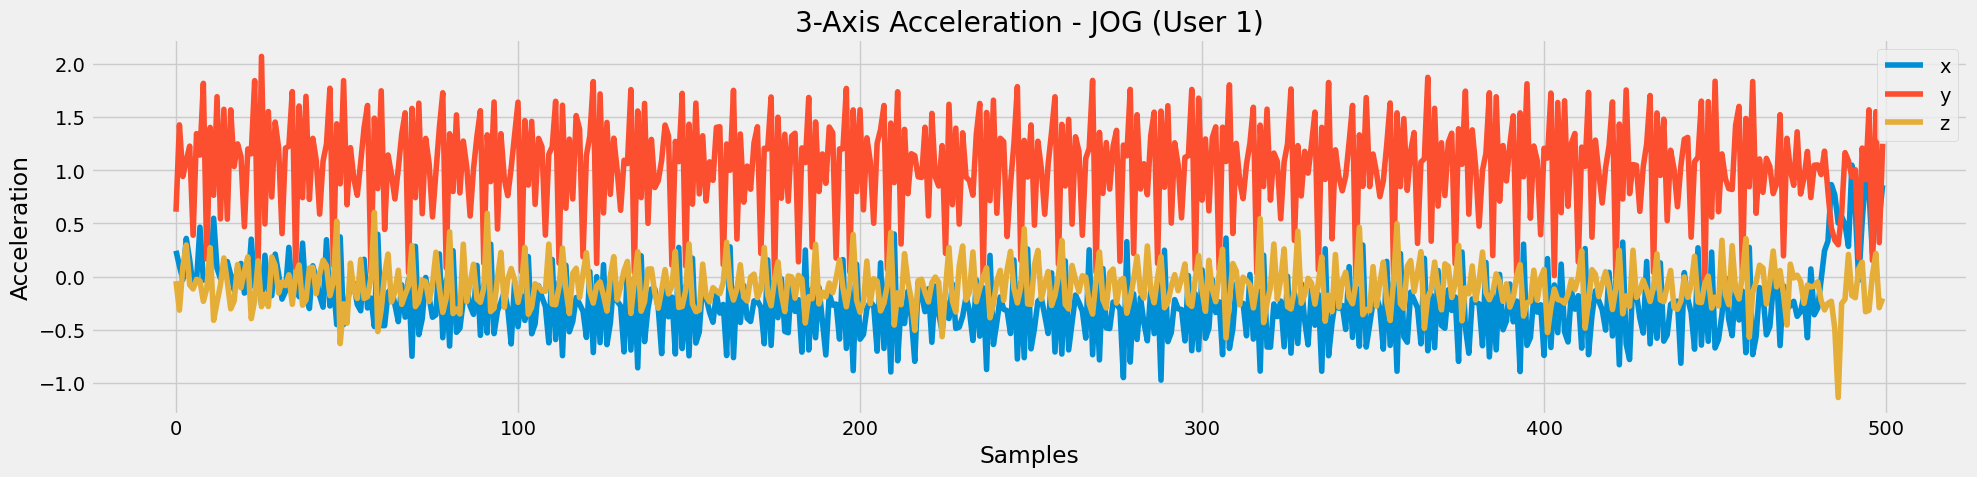

In [ ]:
# 6. Multiple Axes Plot

label = "jog"
user = df[df["category"] == label]["user_id"].iloc[0]

multi_axis_df = (
    df.query(f"category == '{label}' and user_id == {user}")
    .head(500)
    .reset_index(drop=True)
)

plt.figure()
plt.plot(multi_axis_df["acc_x"], label="x")
plt.plot(multi_axis_df["acc_y"], label="y")
plt.plot(multi_axis_df["acc_z"], label="z")
plt.title(f"3-Axis Acceleration - {label.upper()} (User {user})")
plt.xlabel("Samples")
plt.ylabel("Acceleration")
plt.legend()
plt.tight_layout()
plt.savefig(f"../../reports/figures/3axis_{label}_user{user}.png", dpi=150)
plt.show()


Biểu đồ này định lượng mối quan hệ tuyến tính giữa các trục của gia tốc kế và con quay hồi chuyển để kiểm tra tính độc lập của các biến số
=> Xác định liệu có dữ liệu nào bị dư thừa hoặc có mối liên hệ đặc biệt nào giữa các phương hướng chuyển động hay không.

Tính độc lập của cảm biến: Đa số các ô giữa nhóm acc và gyr có giá trị gần bằng 0 (ví dụ: acc_y và gyr_y là 0.04). Điều này chứng tỏ hai loại cảm biến này cung cấp thông tin hoàn toàn khác nhau, không bị trùng lặp.
Mối quan hệ nội tại giữa các trục:
    Tương quan âm giữa acc_x và acc_z (-0.46): Đây là mức tương quan lớn nhất trong ma trận. Điều này phản ánh tư thế vận động: khi thiết bị nghiêng về phía trước (tăng trục X) thì thường có xu hướng giảm ở trục dọc/ngang tương ứng (trục Z).
    Tương quan dương giữa gyr_x và gyr_z (0.52): Cho thấy khi có sự xoay ở trục X, thường sẽ kéo theo sự xoay ở trục Z, phản ánh đặc điểm xoay của cổ tay hoặc cơ thể trong các hoạt động năng động.

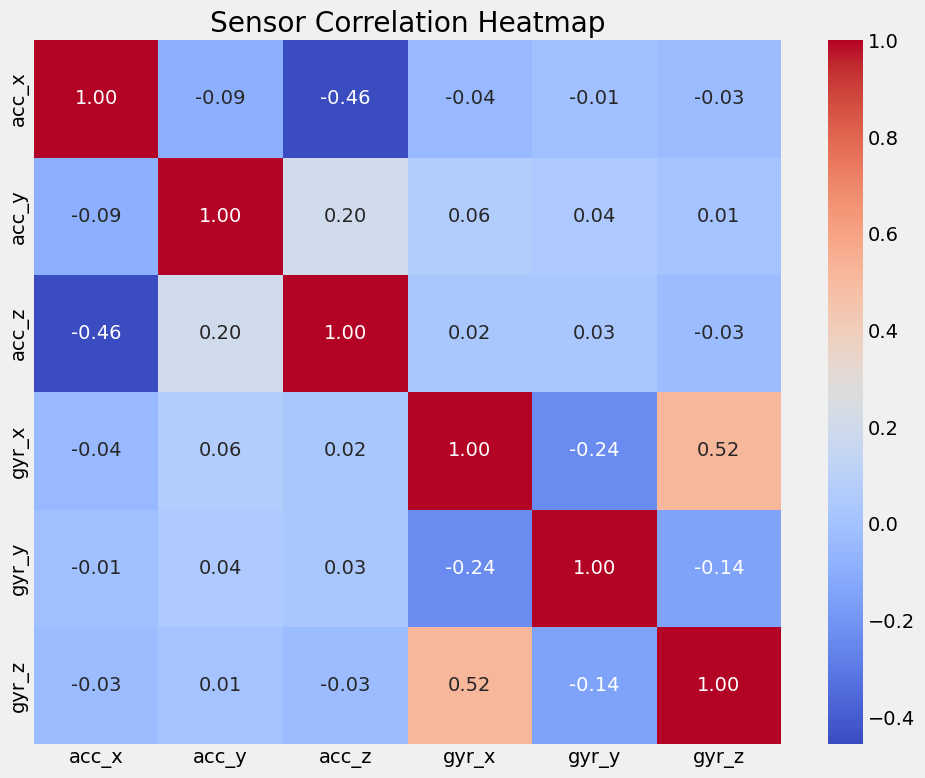

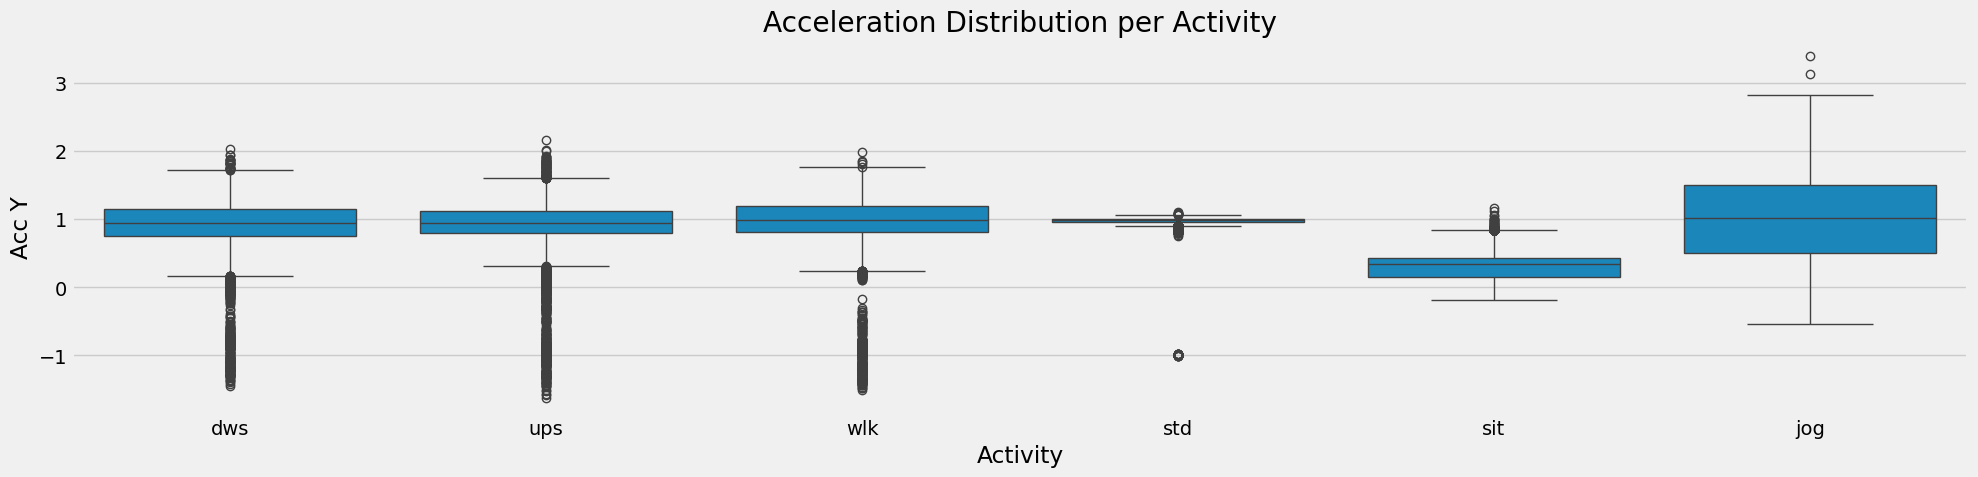

In [10]:

# 7. Distribution and Correlation

corr_df = df[["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Sensor Correlation Heatmap")
plt.tight_layout()
plt.savefig("../../reports/figures/correlation_heatmap.png", dpi=150)
plt.show()

plt.figure()
sns.boxplot(x="category", y="acc_y", data=df)
plt.title("Acceleration Distribution per Activity")
plt.xlabel("Activity")
plt.ylabel("Acc Y")
plt.tight_layout()
plt.savefig("../../reports/figures/boxplot_acc_y.png", dpi=150)
plt.show()


Biểu đồ Scatter Plot này nhằm mục đích trực quan hóa "hình dạng chuyển động" (Motion Shape) bằng cách đối chiếu hai trục Acc X và Acc Y
=> Xác định xem các hoạt động khác nhau có tạo thành các cụm (clusters) riêng biệt trong không gian 2D hay không, từ đó đánh giá khả năSự tập trung trung tâm: Đa số các điểm dữ liệu hội tụ quanh vùng Acc X = 0 và Acc Y = 1. Điều này khớp với thực tế vật lý: khi người dùng di chuyển bình thường, trọng lực chủ yếu tác động lên trục Y (giá trị ~1) và thiết bị cân bằng ở trục X (~0).

Các "đám mây" hoạt động:
- Vùng màu tím (đậm): Tạo thành một đường cong rất mảnh và gọn ngay mức Acc Y = 1. Đây chắc chắn là các trạng thái tĩnh (SIT hoặc STD). Sự tập trung cao độ này cho thấy độ biến thiên cực thấp.
- Vùng màu xám/vàng (lan tỏa rộng): Đây là các hoạt động năng động như JOG và WLK. Chúng tỏa rộng ra cả hai phía của trục X (từ -1 đến 1.5) và trục Y (từ -1 đến 3). Điều này thể hiện sự rung lắc mạnh theo mọi hướng khi vận động nhanh.
- Vùng màu xanh lam (phía dưới): Có một cụm màu xanh nằm tách biệt ở dải Acc Y thấp (khoảng 0 đến 0.5). Điều này cực kỳ quan trọng—nó cho thấy có một hoạt động cụ thể nào đó khiến thiết bị bị nghiêng đi đáng kể so với trọng trường dọc.

Sự chồng lấn (Overlap): Ở trung tâm biểu đồ, các màu sắc trộn lẫn vào nhau rất dày. Điều này báo hiệu rằng nếu chỉ dùng giá trị gia tốc tức thời (raw data) tại một thời điểm, AI sẽ rất khó phân biệt được hoạt động.ng phân loại của dữ liệu.



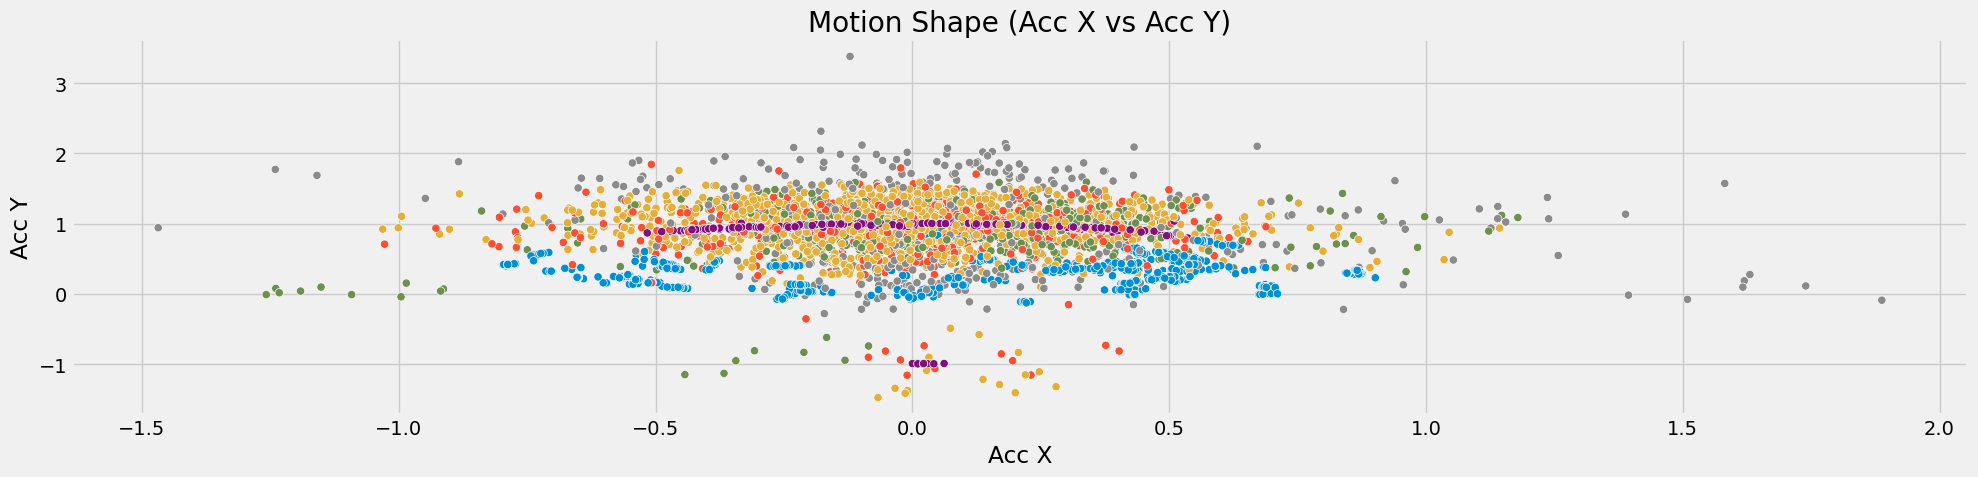

In [11]:

# 8. Motion Shape

scatter_df = df.sample(5000, random_state=42)

plt.figure()
sns.scatterplot(
    x="acc_x",
    y="acc_y",
    hue="category",
    data=scatter_df,
    legend=False
)
plt.title("Motion Shape (Acc X vs Acc Y)")
plt.xlabel("Acc X")
plt.ylabel("Acc Y")
plt.tight_layout()
plt.savefig("../../reports/figures/scatter_motion_shape.png", dpi=150)
plt.show()


In [12]:

# 9. Mass Export Figures

test_users = df["user_id"].unique()[:3]

for label in labels:
    for user in test_users:
        subset = df.query(
            f"category == '{label}' and user_id == {user}"
        ).head(500)

        if subset.empty:
            continue

        fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(20, 10))

        subset[["acc_x", "acc_y", "acc_z"]].plot(ax=ax[0])
        ax[0].set_title(f"{label.upper()} - User {user}")
        ax[0].set_ylabel("Acceleration")

        subset[["gyr_x", "gyr_y", "gyr_z"]].plot(ax=ax[1])
        ax[1].set_ylabel("Gyroscope")
        ax[1].set_xlabel("Samples")

        plt.tight_layout()
        plt.savefig(f"../../reports/figures/{label}_user{user}.png", dpi=150)
        plt.close(fig)